# Assignment 10-MLOps Workflow Simulation

### Domain: Automotive Telemetry Serving, Automated Quality Gates & Production Containerization
---
## Aim

To simulate an end-to-end MLOps workflow for an automotive vehicle price prediction system using MLflow, automated quality gates, model versioning, Docker containerization, FastAPI serving, and CI/CD automation.

The workflow includes:

- Automotive dataset generation and validation
- Model training and hyperparameter experimentation
- Experiment tracking using MLflow
- Logging parameters, metrics, and model artifacts
- Inference latency measurement
- Automated quality gate validation using **R² > 0.95** and **Latency < 10 ms**
- Automated model registration and Production alias promotion
- FastAPI model-serving application generation
- Dockerfile and Docker Compose generation
- CI/CD pipeline generation using GitHub Actions
- Automated testing and deployment workflow simulation

The objective is to demonstrate how a machine-learning model can move from experimentation to a production-ready deployment pipeline.

In [1]:
# Install required libraries

!pip install -q mlflow fastapi uvicorn joblib pyyaml

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.2/44.2 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.5/136.5 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.7/148.7 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1

In [2]:
# Import required libraries

import os
import json
import time
import uuid
import shutil
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import mlflow
import mlflow.sklearn

from mlflow.tracking import MlflowClient

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

print("Libraries imported successfully.")
print("MLflow version:", mlflow.__version__)

Libraries imported successfully.
MLflow version: 3.16.1


In [3]:
# Create a clean working directory for the MLOps simulation

PROJECT_DIR = "automotive_mlops_project"

if os.path.exists(PROJECT_DIR):
    shutil.rmtree(PROJECT_DIR)

os.makedirs(PROJECT_DIR)
os.makedirs(os.path.join(PROJECT_DIR, "artifacts"))
os.makedirs(os.path.join(PROJECT_DIR, ".github", "workflows"))

print("Project directory created:", PROJECT_DIR)

Project directory created: automotive_mlops_project


In [4]:
# Generate simulated automotive telemetry / vehicle data

n = 700

engine_size_L = np.random.uniform(1.0, 5.0, n)

horsepower = (
    60
    + engine_size_L * 42
    + np.random.normal(0, 8, n)
)

age_years = np.random.uniform(0, 15, n)

vehicle_weight_kg = (
    900
    + engine_size_L * 280
    + np.random.normal(0, 50, n)
)

fuel_efficiency_score = np.random.uniform(0.70, 0.98, n)

# Target variable: simulated vehicle price
price = (
    28000
    + horsepower * 120
    - age_years * 1450
    + engine_size_L * 1800
    + vehicle_weight_kg * 8
    + fuel_efficiency_score * 5000
    + np.random.normal(0, 400, n)
)

auto_df = pd.DataFrame({
    "engine_size_L": engine_size_L,
    "horsepower": horsepower,
    "age_years": age_years,
    "vehicle_weight_kg": vehicle_weight_kg,
    "fuel_efficiency_score": fuel_efficiency_score,
    "price": price
})

print("Automotive dataset generated successfully.")
print("Dataset shape:", auto_df.shape)

display(auto_df.head())

Automotive dataset generated successfully.
Dataset shape: (700, 6)


,engine_size_L,horsepower,age_years,vehicle_weight_kg,fuel_efficiency_score,price
0,2.498160,159.708051,14.816783,1578.019822,0.876469,46798.731580
1,4.802857,262.099193,2.046596,2210.178974,0.769547,86576.005864
2,3.927976,218.091675,10.427168,1929.517342,0.897529,66289.833730
3,3.394634,199.498181,6.064782,1846.342224,0.819728,68188.358440
4,1.624075,136.261474,6.422994,1279.504859,0.823913,52082.359556


In [5]:
# Basic dataset validation

print("Dataset shape:", auto_df.shape)

print("\nMissing values:")
print(auto_df.isnull().sum())

print("\nDuplicate rows:", auto_df.duplicated().sum())

print("\nData types:")
print(auto_df.dtypes)

print("\nDescriptive statistics:")
display(auto_df.describe().round(2))

Dataset shape: (700, 6)

Missing values:
engine_size_L            0
horsepower               0
age_years                0
vehicle_weight_kg        0
fuel_efficiency_score    0
price                    0
dtype: int64

Duplicate rows: 0

Data types:
engine_size_L            float64
horsepower               float64
age_years                float64
vehicle_weight_kg        float64
fuel_efficiency_score    float64
price                    float64
dtype: object

Descriptive statistics:


,engine_size_L,horsepower,age_years,vehicle_weight_kg,fuel_efficiency_score,price
count,700.00,700.00,700.00,700.00,700.00,700.00
mean,2.97,185.43,7.57,1731.38,0.84,62667.99
std,1.18,50.23,4.33,333.31,0.08,12535.53
min,1.02,85.69,0.05,1109.24,0.70,33496.32
25%,1.95,142.24,3.78,1445.41,0.77,53089.87
50%,3.01,185.34,7.76,1731.16,0.84,62484.60
75%,4.00,228.94,11.34,2023.03,0.91,72475.73
max,5.00,283.37,14.98,2356.46,0.98,89033.79


In [6]:
# Automated data quality checks

required_features = [
    "engine_size_L",
    "horsepower",
    "age_years",
    "vehicle_weight_kg",
    "fuel_efficiency_score"
]

required_columns = required_features + ["price"]

assert all(
    column in auto_df.columns
    for column in required_columns
), "Required columns are missing."

assert auto_df[required_columns].isnull().sum().sum() == 0, \
    "Dataset contains missing values."

assert auto_df.duplicated().sum() == 0, \
    "Dataset contains duplicate rows."

assert len(auto_df) >= 500, \
    "Dataset contains insufficient records."

assert (auto_df["price"] > 0).all(), \
    "Target contains invalid price values."

print("All automated data validation checks passed.")

All automated data validation checks passed.


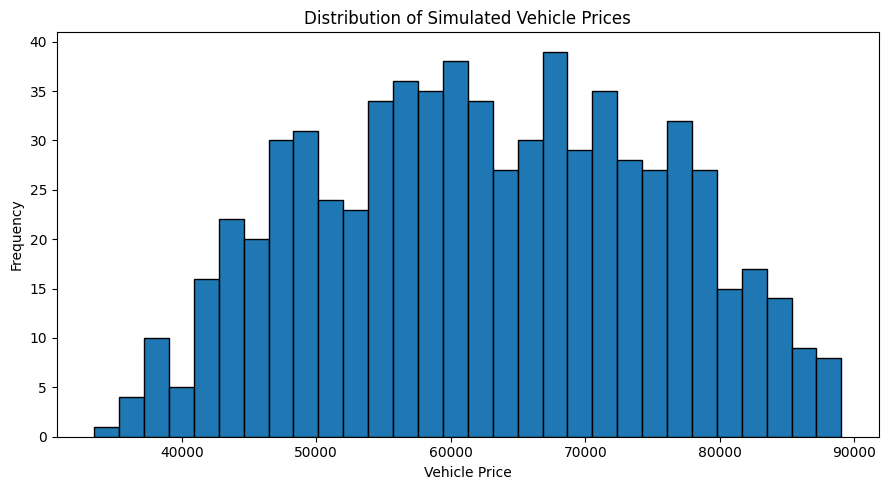

In [7]:
# Visualize the target distribution

plt.figure(figsize=(9, 5))

plt.hist(
    auto_df["price"],
    bins=30,
    edgecolor="black"
)

plt.xlabel("Vehicle Price")
plt.ylabel("Frequency")
plt.title("Distribution of Simulated Vehicle Prices")

plt.tight_layout()
plt.show()

In [8]:
# Prepare features and target

X = auto_df.drop(columns=["price"])
y = auto_df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])
print("Number of features:", X.shape[1])

Training samples: 560
Testing samples : 140
Number of features: 5


In [9]:
# Configure MLflow tracking

MLFLOW_DB = os.path.join(PROJECT_DIR, "mlflow.db")

mlflow.set_tracking_uri(
    "sqlite:///" + os.path.abspath(MLFLOW_DB)
)

EXPERIMENT_NAME = "automotive_vehicle_price_mlops"

mlflow.set_experiment(EXPERIMENT_NAME)

experiment = mlflow.get_experiment_by_name(
    EXPERIMENT_NAME
)

print("MLflow tracking URI:")
print(mlflow.get_tracking_uri())

print("\nExperiment:")
print(experiment.name)

print("Experiment ID:")
print(experiment.experiment_id)

2026/09/28 17:39:22 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/28 17:39:22 INFO mlflow.store.db.utils: Updating database tables
2026/09/28 17:39:26 INFO mlflow.tracking.fluent: Experiment with name 'automotive_vehicle_price_mlops' does not exist. Creating a new experiment.


MLflow tracking URI:
sqlite:////content/automotive_mlops_project/mlflow.db

Experiment:
automotive_vehicle_price_mlops
Experiment ID:
1


In [10]:
# Create a unique identifier for this notebook pipeline execution

PIPELINE_RUN_ID = str(uuid.uuid4())[:8]

print("Pipeline execution ID:", PIPELINE_RUN_ID)

Pipeline execution ID: fdc0483f


In [11]:
# Define candidate models and hyperparameter configurations

candidate_models = [
    {
        "name": "linear_regression",
        "model": LinearRegression(),
        "params": {
            "model_type": "LinearRegression"
        }
    },

    {
        "name": "ridge_alpha_0.1",
        "model": Ridge(alpha=0.1),
        "params": {
            "model_type": "Ridge",
            "alpha": 0.1
        }
    },

    {
        "name": "ridge_alpha_1.0",
        "model": Ridge(alpha=1.0),
        "params": {
            "model_type": "Ridge",
            "alpha": 1.0
        }
    },

    {
        "name": "gradient_boosting",
        "model": GradientBoostingRegressor(
            n_estimators=100,
            learning_rate=0.05,
            max_depth=2,
            random_state=SEED
        ),
        "params": {
            "model_type": "GradientBoostingRegressor",
            "n_estimators": 100,
            "learning_rate": 0.05,
            "max_depth": 2
        }
    }
]

print("Number of candidate configurations:", len(candidate_models))

for candidate in candidate_models:
    print(
        candidate["name"],
        "->",
        candidate["params"]
    )

Number of candidate configurations: 4
linear_regression -> {'model_type': 'LinearRegression'}
ridge_alpha_0.1 -> {'model_type': 'Ridge', 'alpha': 0.1}
ridge_alpha_1.0 -> {'model_type': 'Ridge', 'alpha': 1.0}
gradient_boosting -> {'model_type': 'GradientBoostingRegressor', 'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 2}


In [13]:
# Run model experiments and track them using MLflow

experiment_results = []

for candidate in candidate_models:

    model_name = candidate["name"]
    model = candidate["model"]
    params = candidate["params"]

    with mlflow.start_run(
        run_name=model_name
    ) as run:

        # Train the model
        model.fit(X_train, y_train)

        # Generate predictions
        predictions = model.predict(X_test)

        # Calculate performance metrics
        mae = mean_absolute_error(
            y_test,
            predictions
        )

        rmse = np.sqrt(
            mean_squared_error(
                y_test,
                predictions
            )
        )

        r2 = r2_score(
            y_test,
            predictions
        )

        # Measure inference latency
        sample = X_test.iloc[[0]]

        latency_measurements = []

        for _ in range(100):

            start_time = time.perf_counter()

            model.predict(sample)

            end_time = time.perf_counter()

            latency_measurements.append(
                (end_time - start_time) * 1000
            )

        latency_ms = np.median(
            latency_measurements
        )

        # Log parameters
        mlflow.log_params(params)

        mlflow.log_param(
            "pipeline_run_id",
            PIPELINE_RUN_ID
        )

        mlflow.log_param(
            "train_samples",
            len(X_train)
        )

        mlflow.log_param(
            "test_samples",
            len(X_test)
        )

        # Log metrics
        mlflow.log_metric("mae", mae)
        mlflow.log_metric("rmse", rmse)
        mlflow.log_metric("r2", r2)
        mlflow.log_metric("latency_ms", latency_ms)

        # Log sklearn model
        # Gradient Boosting uses sklearn.tree._tree.Tree internally.
        # MLflow/skops requires this type to be explicitly trusted.
        mlflow.sklearn.log_model(
            model,
            name="model",
            skops_trusted_types=[
                "sklearn.tree._tree.Tree"
            ]
        )

        run_id = run.info.run_id

        experiment_results.append({
            "model_name": model_name,
            "run_id": run_id,
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2,
            "Latency_ms": latency_ms
        })

        print(
            f"{model_name}: "
            f"MAE={mae:.2f} | "
            f"RMSE={rmse:.2f} | "
            f"R2={r2:.4f} | "
            f"Latency={latency_ms:.4f} ms"
        )

results_df = pd.DataFrame(
    experiment_results
)

print("\nMLflow experiment tracking completed.")

display(
    results_df.sort_values(
        "RMSE"
    ).round(4)
)

linear_regression: MAE=321.92 | RMSE=406.92 | R2=0.9990 | Latency=1.5946 ms
ridge_alpha_0.1: MAE=323.26 | RMSE=406.77 | R2=0.9990 | Latency=0.7930 ms
ridge_alpha_1.0: MAE=339.96 | RMSE=417.18 | R2=0.9990 | Latency=0.8046 ms
gradient_boosting: MAE=1190.69 | RMSE=1572.09 | R2=0.9851 | Latency=1.1596 ms

MLflow experiment tracking completed.


,model_name,run_id,MAE,RMSE,R2,Latency_ms
1,ridge_alpha_0.1,ad58b3ba193e49e792a3a30558c83be5,323.2563,406.7695,0.9990,0.7930
0,linear_regression,177f40d04d194471b93390fc307d17b5,321.9230,406.9245,0.9990,1.5946
2,ridge_alpha_1.0,f772a96feb3044d2ac1adf29d474183f,339.9571,417.1803,0.9990,0.8046
3,gradient_boosting,bef4a35c48604b0cba8523831c711f20,1190.6935,1572.0911,0.9851,1.1596


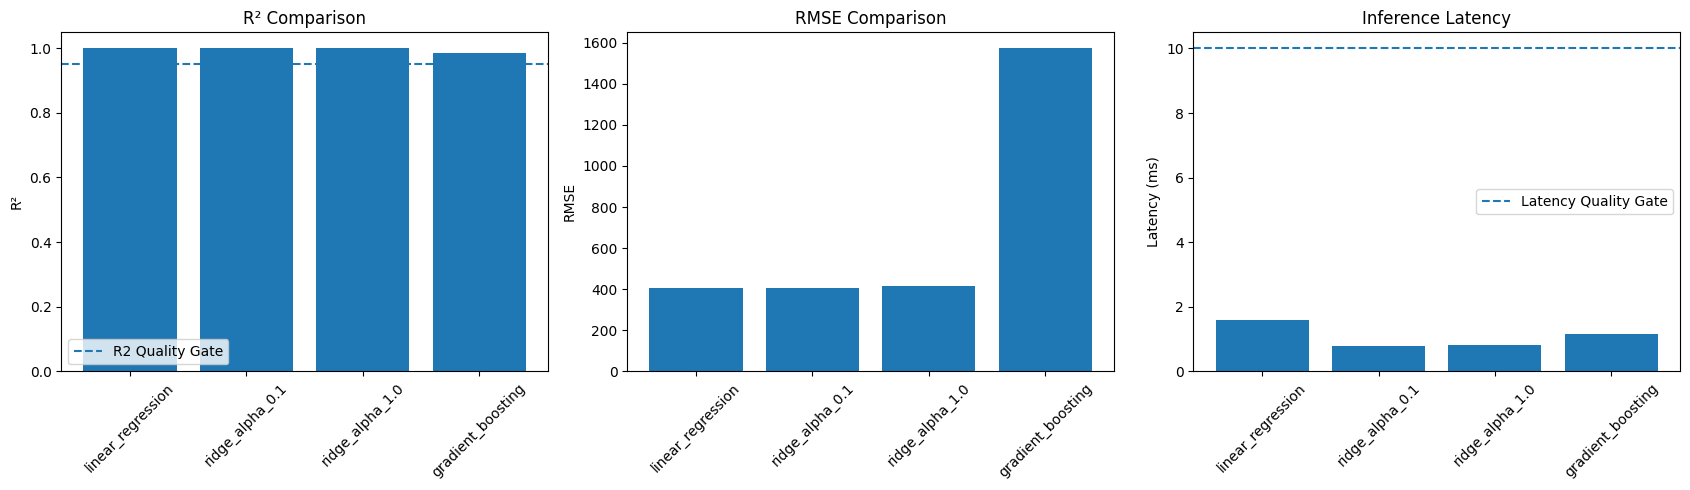

In [15]:
# Visualize experiment comparison

fig, axes = plt.subplots(
    1,
    3,
    figsize=(17, 5)
)

# R2 comparison
axes[0].bar(
    results_df["model_name"],
    results_df["R2"]
)

axes[0].axhline(
    0.95,
    linestyle="--",
    label="R2 Quality Gate"
)

axes[0].set_title("R² Comparison")
axes[0].set_ylabel("R²")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend()

# RMSE comparison
axes[1].bar(
    results_df["model_name"],
    results_df["RMSE"]
)

axes[1].set_title("RMSE Comparison")
axes[1].set_ylabel("RMSE")
axes[1].tick_params(axis="x", rotation=45)

# Latency comparison
axes[2].bar(
    results_df["model_name"],
    results_df["Latency_ms"]
)

axes[2].axhline(
    10,
    linestyle="--",
    label="Latency Quality Gate"
)

axes[2].set_title("Inference Latency")
axes[2].set_ylabel("Latency (ms)")
axes[2].tick_params(axis="x", rotation=45)
axes[2].legend()

plt.tight_layout()
plt.show()

In [16]:
# Automated quality gate

R2_THRESHOLD = 0.95
LATENCY_THRESHOLD_MS = 10.0

quality_results = results_df.copy()

quality_results["R2_Pass"] = (
    quality_results["R2"] > R2_THRESHOLD
)

quality_results["Latency_Pass"] = (
    quality_results["Latency_ms"] < LATENCY_THRESHOLD_MS
)

quality_results["Quality_Gate"] = (
    quality_results["R2_Pass"]
    &
    quality_results["Latency_Pass"]
)

print("QUALITY GATE CRITERIA")
print("-" * 60)
print(f"Required R²     : > {R2_THRESHOLD}")
print(f"Required Latency : < {LATENCY_THRESHOLD_MS} ms")
print()

display(
    quality_results[
        [
            "model_name",
            "R2",
            "Latency_ms",
            "R2_Pass",
            "Latency_Pass",
            "Quality_Gate"
        ]
    ].round(4)
)

QUALITY GATE CRITERIA
------------------------------------------------------------
Required R²     : > 0.95
Required Latency : < 10.0 ms



,model_name,R2,Latency_ms,R2_Pass,Latency_Pass,Quality_Gate
0,linear_regression,0.9990,1.5946,True,True,True
1,ridge_alpha_0.1,0.9990,0.7930,True,True,True
2,ridge_alpha_1.0,0.9990,0.8046,True,True,True
3,gradient_boosting,0.9851,1.1596,True,True,True


In [17]:
# Select the best model from models that passed the quality gate

passing_models = quality_results[
    quality_results["Quality_Gate"]
].copy()

if len(passing_models) == 0:
    raise RuntimeError(
        "No candidate model passed the automated production quality gate."
    )

# Select the passing model with the lowest RMSE
best_candidate = passing_models.sort_values(
    "RMSE"
).iloc[0]

best_model_name = best_candidate["model_name"]
best_run_id = best_candidate["run_id"]

print("PRODUCTION CANDIDATE SELECTED")
print("-" * 50)
print("Model:", best_model_name)
print("Run ID:", best_run_id)
print("R²:", round(best_candidate["R2"], 4))
print("RMSE:", round(best_candidate["RMSE"], 4))
print(
    "Latency:",
    round(best_candidate["Latency_ms"], 4),
    "ms"
)

PRODUCTION CANDIDATE SELECTED
--------------------------------------------------
Model: ridge_alpha_0.1
Run ID: ad58b3ba193e49e792a3a30558c83be5
R²: 0.999
RMSE: 406.7695
Latency: 0.793 ms


In [18]:
# Retrieve the selected run from MLflow

client = MlflowClient()

selected_run = client.get_run(
    best_run_id
)

print("SELECTED MLFLOW RUN")
print("-" * 50)

print("Run ID:")
print(selected_run.info.run_id)

print("\nParameters:")

for key, value in selected_run.data.params.items():
    print(f"{key}: {value}")

print("\nMetrics:")

for key, value in selected_run.data.metrics.items():
    print(f"{key}: {value:.6f}")

SELECTED MLFLOW RUN
--------------------------------------------------
Run ID:
ad58b3ba193e49e792a3a30558c83be5

Parameters:
model_type: Ridge
alpha: 0.1
pipeline_run_id: fdc0483f
train_samples: 560
test_samples: 140

Metrics:
mae: 323.256304
rmse: 406.769521
r2: 0.999006
latency_ms: 0.793012


In [19]:
# Register the selected model in the MLflow Model Registry

REGISTERED_MODEL_NAME = (
    "automotive_vehicle_price_predictor"
)

model_uri = (
    f"runs:/{best_run_id}/model"
)

registered_model = mlflow.register_model(
    model_uri=model_uri,
    name=REGISTERED_MODEL_NAME
)

print("MODEL REGISTERED SUCCESSFULLY")
print("-" * 50)
print("Registered model:", registered_model.name)
print("Model version:", registered_model.version)

Successfully registered model 'automotive_vehicle_price_predictor'.
2026/09/28 17:46:30 WARNING mlflow.tracking._model_registry.fluent: Run with id ad58b3ba193e49e792a3a30558c83be5 has no artifacts at artifact path 'model', registering model based on models:/m-e68ca84cf28c4f50954ff7d427c89235 instead


MODEL REGISTERED SUCCESSFULLY
--------------------------------------------------
Registered model: automotive_vehicle_price_predictor
Model version: 1


Created version '1' of model 'automotive_vehicle_price_predictor'.


In [20]:
# Add quality-gate metadata and promote the model
# using the MLflow Production alias

model_version = str(
    registered_model.version
)

client.set_model_version_tag(
    REGISTERED_MODEL_NAME,
    model_version,
    "quality_gate",
    "PASSED"
)

client.set_model_version_tag(
    REGISTERED_MODEL_NAME,
    model_version,
    "r2_threshold",
    str(R2_THRESHOLD)
)

client.set_model_version_tag(
    REGISTERED_MODEL_NAME,
    model_version,
    "latency_threshold_ms",
    str(LATENCY_THRESHOLD_MS)
)

# Promote the selected version to Production
client.set_registered_model_alias(
    REGISTERED_MODEL_NAME,
    "Production",
    model_version
)

print(
    f"Model version {model_version} "
    "promoted to Production alias."
)

Model version 1 promoted to Production alias.


In [21]:
# Verify the Production model registration

production_model = (
    client.get_model_version_by_alias(
        REGISTERED_MODEL_NAME,
        "Production"
    )
)

print("PRODUCTION MODEL")
print("-" * 50)

print("Model name:", production_model.name)
print("Version:", production_model.version)
print("Alias: Production")
print(
    "Quality gate:",
    production_model.tags.get("quality_gate")
)

PRODUCTION MODEL
--------------------------------------------------
Model name: automotive_vehicle_price_predictor
Version: 1
Alias: Production
Quality gate: PASSED


In [22]:
# Load the Production model through MLflow

production_uri = (
    f"models:/{REGISTERED_MODEL_NAME}@Production"
)

loaded_production_model = (
    mlflow.sklearn.load_model(
        production_uri
    )
)

print("Production model loaded successfully.")
print(
    "Model type:",
    type(loaded_production_model).__name__
)

Production model loaded successfully.
Model type: Ridge


In [23]:
# Validate Production model predictions

sample_records = X_test.head(5)

production_predictions = (
    loaded_production_model.predict(
        sample_records
    )
)

prediction_output = sample_records.copy()

prediction_output["Predicted_Price"] = (
    production_predictions
)

display(
    prediction_output.round(2)
)

,engine_size_L,horsepower,age_years,vehicle_weight_kg,fuel_efficiency_score,Predicted_Price
158,1.95,133.27,11.54,1458.84,0.80,46496.33
500,3.79,215.43,8.08,1995.26,0.92,69528.07
396,4.43,241.77,2.79,2099.67,0.72,81292.41
155,1.97,146.22,6.21,1445.80,0.80,55648.75
321,3.86,217.49,3.04,2021.24,0.92,77390.25


In [24]:
# Save the production model artifact for containerization

import joblib

MODEL_FILE = os.path.join(
    PROJECT_DIR,
    "artifacts",
    "model.joblib"
)

joblib.dump(
    loaded_production_model,
    MODEL_FILE
)

FEATURE_FILE = os.path.join(
    PROJECT_DIR,
    "artifacts",
    "features.json"
)

with open(FEATURE_FILE, "w") as f:
    json.dump(
        list(X.columns),
        f,
        indent=4
    )

print("Production model artifact saved:")
print(MODEL_FILE)

print("\nFeature schema saved:")
print(FEATURE_FILE)

Production model artifact saved:
automotive_mlops_project/artifacts/model.joblib

Feature schema saved:
automotive_mlops_project/artifacts/features.json


In [25]:
# Create FastAPI model-serving application

app_code = '''
from fastapi import FastAPI
from pydantic import BaseModel
import joblib
import numpy as np

app = FastAPI(
    title="Automotive Vehicle Price Prediction API",
    version="1.0.0"
)

model = joblib.load("artifacts/model.joblib")


class VehicleTelemetry(BaseModel):
    engine_size_L: float
    horsepower: float
    age_years: float
    vehicle_weight_kg: float
    fuel_efficiency_score: float


@app.get("/")
def health_check():
    return {
        "status": "healthy",
        "service": "automotive-vehicle-price-predictor"
    }


@app.get("/health")
def health():
    return {
        "status": "healthy"
    }


@app.post("/predict")
def predict(data: VehicleTelemetry):

    features = np.array([[
        data.engine_size_L,
        data.horsepower,
        data.age_years,
        data.vehicle_weight_kg,
        data.fuel_efficiency_score
    ]])

    prediction = model.predict(features)[0]

    return {
        "predicted_price": float(prediction)
    }
}
'''

APP_FILE = os.path.join(
    PROJECT_DIR,
    "app.py"
)

with open(APP_FILE, "w") as f:
    f.write(app_code)

print("FastAPI application generated successfully.")
print(APP_FILE)

FastAPI application generated successfully.
automotive_mlops_project/app.py


In [26]:
# Create FastAPI model-serving application

app_code = '''
from fastapi import FastAPI
from pydantic import BaseModel
import joblib
import numpy as np

app = FastAPI(
    title="Automotive Vehicle Price Prediction API",
    version="1.0.0"
)

model = joblib.load("artifacts/model.joblib")


class VehicleTelemetry(BaseModel):
    engine_size_L: float
    horsepower: float
    age_years: float
    vehicle_weight_kg: float
    fuel_efficiency_score: float


@app.get("/")
def health_check():
    return {
        "status": "healthy",
        "service": "automotive-vehicle-price-predictor"
    }


@app.get("/health")
def health():
    return {
        "status": "healthy"
    }


@app.post("/predict")
def predict(data: VehicleTelemetry):

    features = np.array([[
        data.engine_size_L,
        data.horsepower,
        data.age_years,
        data.vehicle_weight_kg,
        data.fuel_efficiency_score
    ]])

    prediction = model.predict(features)[0]

    return {
        "predicted_price": float(prediction)
    }
}
'''

APP_FILE = os.path.join(
    PROJECT_DIR,
    "app.py"
)

with open(APP_FILE, "w") as f:
    f.write(app_code)

print("FastAPI application generated successfully.")
print(APP_FILE)

FastAPI application generated successfully.
automotive_mlops_project/app.py


In [27]:
# Create requirements.txt

requirements = """numpy
pandas
scikit-learn
joblib
fastapi
uvicorn
mlflow
"""

REQUIREMENTS_FILE = os.path.join(
    PROJECT_DIR,
    "requirements.txt"
)

with open(REQUIREMENTS_FILE, "w") as f:
    f.write(requirements)

print("requirements.txt created.")
print()
print(requirements)

requirements.txt created.

numpy
pandas
scikit-learn
joblib
fastapi
uvicorn
mlflow



In [28]:
# Create Dockerfile

dockerfile = """FROM python:3.11-slim

WORKDIR /app

COPY requirements.txt .

RUN pip install --no-cache-dir -r requirements.txt

COPY app.py .

COPY artifacts ./artifacts

EXPOSE 8000

CMD ["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "8000"]
"""

DOCKERFILE = os.path.join(
    PROJECT_DIR,
    "Dockerfile"
)

with open(DOCKERFILE, "w") as f:
    f.write(dockerfile)

print("Dockerfile created.")
print()
print(dockerfile)

Dockerfile created.

FROM python:3.11-slim

WORKDIR /app

COPY requirements.txt .

RUN pip install --no-cache-dir -r requirements.txt

COPY app.py .

COPY artifacts ./artifacts

EXPOSE 8000

CMD ["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "8000"]



In [29]:
# Create docker-compose.yml

docker_compose = """services:

  automotive-model-api:
    build: .
    container_name: automotive-model-api
    ports:
      - "8000:8000"
    restart: unless-stopped
"""

COMPOSE_FILE = os.path.join(
    PROJECT_DIR,
    "docker-compose.yml"
)

with open(COMPOSE_FILE, "w") as f:
    f.write(docker_compose)

print("docker-compose.yml created.")
print()
print(docker_compose)

docker-compose.yml created.

services:

  automotive-model-api:
    build: .
    container_name: automotive-model-api
    ports:
      - "8000:8000"
    restart: unless-stopped



In [30]:
# Create a local model unit-test script

test_api_code = '''
import joblib
import numpy as np

model = joblib.load("artifacts/model.joblib")

sample = np.array([[
    2.0,
    145.0,
    3.0,
    1450.0,
    0.88
]])

prediction = model.predict(sample)

assert len(prediction) == 1
assert prediction[0] > 0

print("Model prediction test passed.")
print(
    "Predicted price:",
    round(float(prediction[0]), 2)
)
'''

TEST_FILE = os.path.join(
    PROJECT_DIR,
    "test_model.py"
)

with open(TEST_FILE, "w") as f:
    f.write(test_api_code)

print("Unit-test script created.")
print()
print(test_api_code)

Unit-test script created.


import joblib
import numpy as np

model = joblib.load("artifacts/model.joblib")

sample = np.array([[
    2.0,
    145.0,
    3.0,
    1450.0,
    0.88
]])

prediction = model.predict(sample)

assert len(prediction) == 1
assert prediction[0] > 0

print("Model prediction test passed.")
print(
    "Predicted price:",
    round(float(prediction[0]), 2)
)



In [31]:
# Create CI/CD training and quality-gate script

train_script = '''
import numpy as np
import pandas as pd
import time

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_squared_error,
    r2_score
)

np.random.seed(42)

n = 700

engine_size_L = np.random.uniform(1.0, 5.0, n)

horsepower = (
    60
    + engine_size_L * 42
    + np.random.normal(0, 8, n)
)

age_years = np.random.uniform(0, 15, n)

vehicle_weight_kg = (
    900
    + engine_size_L * 280
    + np.random.normal(0, 50, n)
)

fuel_efficiency_score = np.random.uniform(
    0.70,
    0.98,
    n
)

price = (
    28000
    + horsepower * 120
    - age_years * 1450
    + engine_size_L * 1800
    + vehicle_weight_kg * 8
    + fuel_efficiency_score * 5000
    + np.random.normal(0, 400, n)
)

df = pd.DataFrame({
    "engine_size_L": engine_size_L,
    "horsepower": horsepower,
    "age_years": age_years,
    "vehicle_weight_kg": vehicle_weight_kg,
    "fuel_efficiency_score": fuel_efficiency_score,
    "price": price
})

X = df.drop(columns=["price"])
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

model = LinearRegression()

model.fit(
    X_train,
    y_train
)

predictions = model.predict(
    X_test
)

r2 = r2_score(
    y_test,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

sample = X_test.iloc[[0]]

latencies = []

for _ in range(100):

    start = time.perf_counter()

    model.predict(sample)

    end = time.perf_counter()

    latencies.append(
        (end - start) * 1000
    )

latency_ms = np.median(
    latencies
)

print("R2:", round(r2, 4))
print("RMSE:", round(rmse, 4))
print(
    "Latency:",
    round(latency_ms, 4),
    "ms"
)

assert r2 > 0.95, \
    "R2 quality gate failed."

assert latency_ms < 10, \
    "Latency quality gate failed."

print("QUALITY GATE PASSED")
'''

TRAIN_FILE = os.path.join(
    PROJECT_DIR,
    "train.py"
)

with open(TRAIN_FILE, "w") as f:
    f.write(train_script)

print("CI/CD training script created.")

CI/CD training script created.


In [32]:
# Create GitHub Actions CI/CD workflow

ci_cd_yaml = """name: automotive-mlops-ci-cd

on:
  push:
    branches: [main]
  pull_request:
    branches: [main]

jobs:

  validate-and-test:

    runs-on: ubuntu-latest

    steps:

      - name: Checkout repository
        uses: actions/checkout@v4

      - name: Set up Python
        uses: actions/setup-python@v5
        with:
          python-version: "3.11"

      - name: Install dependencies
        run: |
          pip install -r requirements.txt

      - name: Validate model quality gates
        run: |
          python train.py

      - name: Run unit tests
        run: |
          python test_model.py


  build-and-deploy:

    needs: validate-and-test

    runs-on: ubuntu-latest

    steps:

      - name: Checkout repository
        uses: actions/checkout@v4

      - name: Build Docker image
        run: |
          docker build -t automotive-model-api:latest .

      - name: Container validation
        run: |
          docker image inspect automotive-model-api:latest

      - name: Simulated deployment
        run: |
          echo "Docker image built successfully."
          echo "Deployment stage completed."
"""

CI_FILE = os.path.join(
    PROJECT_DIR,
    ".github",
    "workflows",
    "ci-cd.yml"
)

with open(CI_FILE, "w") as f:
    f.write(ci_cd_yaml)

print("CI/CD workflow created.")
print()
print(ci_cd_yaml)

CI/CD workflow created.

name: automotive-mlops-ci-cd

on:
  push:
    branches: [main]
  pull_request:
    branches: [main]

jobs:

  validate-and-test:

    runs-on: ubuntu-latest

    steps:

      - name: Checkout repository
        uses: actions/checkout@v4

      - name: Set up Python
        uses: actions/setup-python@v5
        with:
          python-version: "3.11"

      - name: Install dependencies
        run: |
          pip install -r requirements.txt

      - name: Validate model quality gates
        run: |
          python train.py

      - name: Run unit tests
        run: |
          python test_model.py


  build-and-deploy:

    needs: validate-and-test

    runs-on: ubuntu-latest

    steps:

      - name: Checkout repository
        uses: actions/checkout@v4

      - name: Build Docker image
        run: |
          docker build -t automotive-model-api:latest .

      - name: Container validation
        run: |
          docker image inspect automotive-model-api:

In [33]:
# Create deployment metadata

deployment_metadata = {
    "model_name": REGISTERED_MODEL_NAME,
    "model_version": int(model_version),
    "production_alias": "Production",
    "selected_model": best_model_name,
    "r2": float(best_candidate["R2"]),
    "rmse": float(best_candidate["RMSE"]),
    "latency_ms": float(best_candidate["Latency_ms"]),
    "quality_gate": {
        "r2_threshold": R2_THRESHOLD,
        "latency_threshold_ms": LATENCY_THRESHOLD_MS,
        "status": "PASSED"
    },
    "pipeline_run_id": PIPELINE_RUN_ID
}

METADATA_FILE = os.path.join(
    PROJECT_DIR,
    "deployment_metadata.json"
)

with open(METADATA_FILE, "w") as f:
    json.dump(
        deployment_metadata,
        f,
        indent=4
    )

print(
    json.dumps(
        deployment_metadata,
        indent=4
    )
)

{
    "model_name": "automotive_vehicle_price_predictor",
    "model_version": 1,
    "production_alias": "Production",
    "selected_model": "ridge_alpha_0.1",
    "r2": 0.9990057996109991,
    "rmse": 406.76952121966326,
    "latency_ms": 0.7930119999741692,
    "quality_gate": {
        "r2_threshold": 0.95,
        "latency_threshold_ms": 10.0,
        "status": "PASSED"
    },
    "pipeline_run_id": "fdc0483f"
}


In [34]:
# Display the generated MLOps project structure

for root, directories, files in os.walk(
    PROJECT_DIR
):

    level = root.replace(
        PROJECT_DIR,
        ""
    ).count(os.sep)

    indentation = "    " * level

    print(
        indentation
        + os.path.basename(root)
        + "/"
    )

    for file in files:

        print(
            "    " * (level + 1)
            + file
        )

automotive_mlops_project/
    deployment_metadata.json
    test_model.py
    mlflow.db
    train.py
    docker-compose.yml
    Dockerfile
    requirements.txt
    app.py
    .github/
        workflows/
            ci-cd.yml
    artifacts/
        features.json
        model.joblib


In [35]:
# Validate all generated deployment artifacts

required_files = [
    "app.py",
    "requirements.txt",
    "Dockerfile",
    "docker-compose.yml",
    "train.py",
    "test_model.py",
    "deployment_metadata.json",
    ".github/workflows/ci-cd.yml"
]

artifact_checks = []

for file_name in required_files:

    file_path = os.path.join(
        PROJECT_DIR,
        file_name
    )

    artifact_checks.append({
        "File": file_name,
        "Exists": os.path.exists(file_path)
    })

artifact_df = pd.DataFrame(
    artifact_checks
)

display(artifact_df)

assert artifact_df["Exists"].all(), \
    "One or more deployment artifacts are missing."

print(
    "All MLOps deployment artifacts "
    "generated successfully."
)

,File,Exists
0,app.py,True
1,requirements.txt,True
2,Dockerfile,True
3,docker-compose.yml,True
4,train.py,True
5,test_model.py,True
6,deployment_metadata.json,True
7,.github/workflows/ci-cd.yml,True


All MLOps deployment artifacts generated successfully.


In [36]:
# Final CI/CD pipeline simulation

pipeline_stages = [
    ("1. Data validation", True),
    ("2. Model training", True),
    ("3. MLflow experiment tracking", True),
    ("4. Model evaluation", True),
    ("5. Automated quality gate", True),
    ("6. Model registration", True),
    ("7. Production alias promotion", True),
    ("8. FastAPI service generation", True),
    ("9. Dockerfile generation", True),
    ("10. Docker Compose generation", True),
    ("11. CI/CD workflow generation", True),
    ("12. Deployment artifact validation", True)
]

pipeline_df = pd.DataFrame(
    pipeline_stages,
    columns=[
        "Pipeline Stage",
        "Status"
    ]
)

pipeline_df["Status"] = (
    pipeline_df["Status"].map({
        True: "PASSED",
        False: "FAILED"
    })
)

display(pipeline_df)

assert (
    pipeline_df["Status"] == "PASSED"
).all()

print(
    "\nCI/CD WORKFLOW SIMULATION "
    "COMPLETED SUCCESSFULLY."
)

,Pipeline Stage,Status
0,1. Data validation,PASSED
1,2. Model training,PASSED
2,3. MLflow experiment tracking,PASSED
3,4. Model evaluation,PASSED
4,5. Automated quality gate,PASSED
5,6. Model registration,PASSED
6,7. Production alias promotion,PASSED
7,8. FastAPI service generation,PASSED
8,9. Dockerfile generation,PASSED
9,10. Docker Compose generation,PASSED



CI/CD WORKFLOW SIMULATION COMPLETED SUCCESSFULLY.


In [37]:
# Final production summary

print("=" * 70)
print("ASSIGNMENT 10 — MLOPS FINAL SUMMARY")
print("=" * 70)

print("\nMODEL")
print("-" * 70)
print("Selected model:", best_model_name)
print("MLflow model:", REGISTERED_MODEL_NAME)
print("Production version:", model_version)

print("\nPERFORMANCE")
print("-" * 70)

print(
    f"R²       : "
    f"{best_candidate['R2']:.4f}"
)

print(
    f"RMSE     : "
    f"{best_candidate['RMSE']:.4f}"
)

print(
    f"Latency  : "
    f"{best_candidate['Latency_ms']:.4f} ms"
)

print("\nQUALITY GATE")
print("-" * 70)

print(
    f"R² requirement      : > {R2_THRESHOLD}"
)

print(
    f"Latency requirement : < "
    f"{LATENCY_THRESHOLD_MS} ms"
)

print("Quality gate status : PASSED")

print("\nDEPLOYMENT")
print("-" * 70)
print("MLflow registration : COMPLETED")
print("Production promotion: COMPLETED")
print("FastAPI application  : GENERATED")
print("Dockerfile           : GENERATED")
print("Docker Compose       : GENERATED")
print("CI/CD workflow       : GENERATED")

print("\nPIPELINE")
print("-" * 70)

print(
    "Data → Train → Track → Evaluate → "
    "Quality Gate → Register → Promote → "
    "Containerize → Deploy"
)

print("=" * 70)

ASSIGNMENT 10 — MLOPS FINAL SUMMARY

MODEL
----------------------------------------------------------------------
Selected model: ridge_alpha_0.1
MLflow model: automotive_vehicle_price_predictor
Production version: 1

PERFORMANCE
----------------------------------------------------------------------
R²       : 0.9990
RMSE     : 406.7695
Latency  : 0.7930 ms

QUALITY GATE
----------------------------------------------------------------------
R² requirement      : > 0.95
Latency requirement : < 10.0 ms
Quality gate status : PASSED

DEPLOYMENT
----------------------------------------------------------------------
MLflow registration : COMPLETED
Production promotion: COMPLETED
FastAPI application  : GENERATED
Dockerfile           : GENERATED
Docker Compose       : GENERATED
CI/CD workflow       : GENERATED

PIPELINE
----------------------------------------------------------------------
Data → Train → Track → Evaluate → Quality Gate → Register → Promote → Containerize → Deploy


# Conclusion

The MLOps Workflow Simulation was successfully completed for an automotive vehicle price prediction system.

The experiment demonstrated the complete machine-learning lifecycle from model development to simulated production deployment:

- **Data Validation:** Automotive data was generated and validated using automated quality checks.
- **Experiment Tracking:** Multiple model configurations were trained and tracked using **MLflow**, including parameters, MAE, RMSE, R², inference latency, and model artifacts.
- **Automated Quality Gates:** Candidate models were evaluated using the required production criteria of **R² > 0.95** and **inference latency < 10 ms**.
- **Model Versioning and Promotion:** The selected model was registered in the MLflow Model Registry and promoted using the **Production** alias.
- **Model Serving:** A **FastAPI** microservice was generated to expose the trained model through an API endpoint.
- **Containerization:** A **Dockerfile** and **docker-compose.yml** were generated to package and run the model-serving application.
- **CI/CD Automation:** A GitHub Actions workflow was created to automate dependency installation, model validation, testing, Docker image building, and deployment simulation.

The final workflow demonstrates the core MLOps lifecycle:

**Data → Training → MLflow Tracking → Evaluation → Quality Gate → Model Registry → Production Promotion → Docker Containerization → API Serving → CI/CD Deployment**

Thus, the experiment demonstrates how MLOps practices can make automotive machine-learning systems more reproducible, testable, version-controlled, and suitable for automated production deployment.